# Disk Array Survival Probability

Probability that a RAID array **loses no data** over $t$ years, assuming **no disk replacement**.

## AFR from MTBF

$$\text{AFR} = 1 - e^{-8766 / \text{MTBF}} \approx \frac{8766}{\text{MTBF}}$$

| Type | MTBF | Spec AFR |
|---|---|---|
| Consumer HDD (WD Blue, Barracuda) | 1,000,000 h | ~0.87% |
| NAS HDD (Red Plus, IronWolf) | 1,000,000 h | ~0.87% |
| Enterprise HDD (Exos, Ultrastar) | 2,500,000 h | ~0.35% |
| Consumer SSD (870 EVO) | 1,500,000 h | ~0.58% |
| Enterprise SSD (PM9A3) | 2,000,000 h | ~0.44% |

## Backblaze observed AFRs

[Drive Stats 2024](https://www.backblaze.com/blog/backblaze-drive-stats-for-2024/) · [2025 reports](https://www.backblaze.com/cloud-storage/resources/hard-drive-test-data)

| Segment | AFR |
|---|---|
| Fleet lifetime (300k+ drives) | **1.31%** |
| Fleet 2024 / 2025 | 1.57% / 1.36% |
| 20TB+ pool | 0.72–0.77% |
| Best model (Seagate 16TB) | 0.22% |
| Aging outliers (7+ yr) | 5–10% |

**Takeaway**: Specs imply 0.3–0.9% AFR; real-world fleet average is **~1.3%**. Use **1–2%** for planning.

## Model

Per-disk cumulative failure after $t$ years: $\;p(t) = 1 - (1 - \text{AFR})^t$

Array of $n$ disks tolerating $k$ failures (e.g. RAID-Z2 → $k{=}2$):

$$P_{\text{survive}}(t) = \sum_{i=0}^{k} \binom{n}{i}\, p(t)^{i}\,(1 - p(t))^{n-i}$$

> Simplified worst-case — assumes no rebuilds onto hot spares.

In [1]:
from math import comb
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def survival_probability(n: int, k: int, afr: float, years: np.ndarray) -> np.ndarray:
    """
    Survival probability of an n-disk array tolerating up to k failures,
    given a constant annual failure rate (AFR), over the specified years (no replacement).
    """
    p = 1 - (1 - afr) ** years  # cumulative per-disk failure probability
    return np.array([
        sum(comb(n, i) * (pt ** i) * ((1 - pt) ** (n - i)) for i in range(k + 1))
        for pt in p
    ])

def survival_probability_varying(n: int, k: int, afrs: np.ndarray) -> np.ndarray:
    """
    Survival probability with a per-year AFR that changes over time (bathtub curve).
    afrs[i] is the AFR for year i+1. Cumulative failure prob compounds year by year.
    """
    # cumulative survival per disk through year t = product of (1 - afr_i)
    cum_survive = np.cumprod(1 - afrs)
    p = 1 - cum_survive  # cumulative per-disk failure probability
    return np.array([
        sum(comb(n, i) * (pt ** i) * ((1 - pt) ** (n - i)) for i in range(k + 1))
        for pt in p
    ])

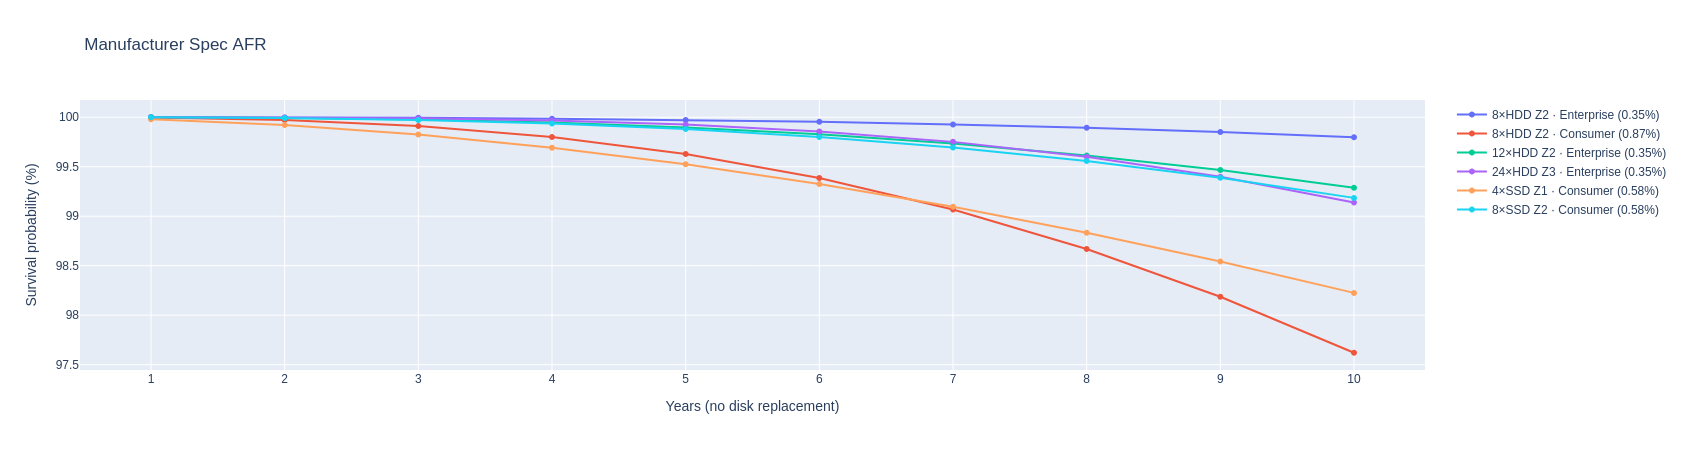

In [2]:
MAX_YEARS = 10
years = np.arange(1, MAX_YEARS + 1)

# --- Spec AFR scenarios (manufacturer MTBF-derived, constant) ---
# Enterprise HDD: 2.5M h MTBF → 0.35% AFR
# Consumer/NAS HDD: 1M h MTBF → 0.87% AFR
# Consumer SSD: 1.5M h MTBF → 0.58% AFR
spec_scenarios = [
    ("8×HDD Z2 · Enterprise (0.35%)",   8, 2, 0.0035),
    ("8×HDD Z2 · Consumer (0.87%)",     8, 2, 0.0087),
    ("12×HDD Z2 · Enterprise (0.35%)", 12, 2, 0.0035),
    ("24×HDD Z3 · Enterprise (0.35%)", 24, 3, 0.0035),
    ("4×SSD Z1 · Consumer (0.58%)",     4, 1, 0.0058),
    ("8×SSD Z2 · Consumer (0.58%)",     8, 2, 0.0058),
]

# --- Real-world AFR scenarios (Backblaze observed) ---
# Bathtub multiplier: 1× years 1-4, 2× years 5-6, 4× years 7+
def bathtub_afrs(base_afr, n_years=10):
    return np.array([
        base_afr * (1 if y <= 4 else 2 if y <= 6 else 4)
        for y in range(1, n_years + 1)
    ])

AFR_20TB = 0.007   # Backblaze 20TB+ pool
AFR_LIFE = 0.013   # Backblaze fleet lifetime

# (label, n_disks, max_failures, base_afr)
real_configs = [
    ("8×HDD Z2",  8, 2),
    ("12×HDD Z2", 12, 2),
    ("24×HDD Z3", 24, 3),
]

spec_results = {l: survival_probability(n, k, a, years) for l, n, k, a in spec_scenarios}

real_results = {}
for label, n, k in real_configs:
    for afr_name, afr in [("20TB+", AFR_20TB), ("Lifetime", AFR_LIFE)]:
        key = f"{label} · {afr_name} ({afr:.1%})"
        real_results[key] = survival_probability_varying(n, k, bathtub_afrs(afr))

fig = go.Figure()
for label, probs in spec_results.items():
    fig.add_trace(go.Scatter(x=years, y=probs * 100, mode="lines+markers", name=label))
fig.update_xaxes(title_text="Years (no disk replacement)", dtick=1)
fig.update_yaxes(title_text="Survival probability (%)")
fig.update_layout(title_text="Manufacturer Spec AFR", height=450, width=900)
fig.show()

### Real-world simulation

Applies a **bathtub curve** multiplier to Backblaze base AFRs:

| Years | Multiplier | Rationale |
|---|---|---|
| 1–4 | 1× | Prime working life |
| 5–6 | 2× | Early wear-out |
| 7+ | 4× | End-of-life (matches 5–10% outliers) |

Base rates: **0.7%** (20TB+ pool) · **1.3%** (fleet lifetime)

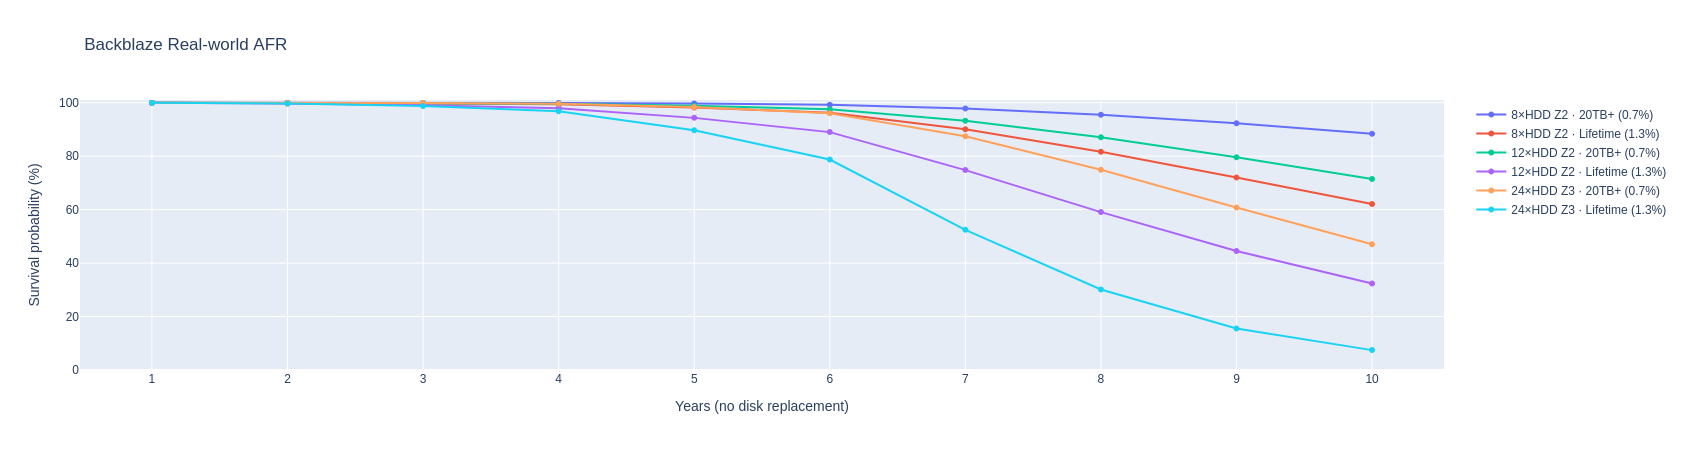

In [3]:
fig = go.Figure()
for label, probs in real_results.items():
    fig.add_trace(go.Scatter(x=years, y=probs * 100, mode="lines+markers", name=label))
fig.update_xaxes(title_text="Years (no disk replacement)", dtick=1)
fig.update_yaxes(title_text="Survival probability (%)", range=[0, 101])
fig.update_layout(title_text="Backblaze Real-world AFR", height=450, width=900)
fig.show()